In [ ]:
import time
import joblib
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import sys
sys.path.append('/home/dangtrxn/cs4742_nlp/AmazonReview_Project')

# for data processing
from src.scraper import preprocess_remove_stopwords

# for NLP tasks
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'src'

In [9]:
# function to map star ratings to sentiment levels
def map_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

In [ ]:
# load dataset
root_dir = Path().resolve().parent
data_path = root_dir / 'data' / 'reviews.csv'
data = pd.read_csv(data_path, delimiter=',')

# only keep Summary, Text, Score, HelpfulnessNumerator columns
data = data[['Summary','Text','Score','HelpfulnessNumerator']]

# rename columns
data.rename(columns={"Summary": "title", "Text": "text", "Score": "rating", "HelpfulnessNumerator": "helpfulVotes"}, inplace=True)

# transform rating to sentiment mapping
data['sentiment'] = data['rating'].apply(map_sentiment)

# drop missing
data = data.dropna()

# preprocess
data = preprocess_remove_stopwords(data)

# display dataset info and the first 5 rows
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   title         568454 non-null  object
 1   text          568454 non-null  object
 2   rating        568454 non-null  int64 
 3   helpfulVotes  568454 non-null  int64 
 4   sentiment     568454 non-null  str   
dtypes: int64(2), object(2), str(1)
memory usage: 21.7+ MB


In [11]:
data.head()

,title,text,rating,helpfulVotes,sentiment
0,"[good, quality, dog, food]","[bought, several, vitality, canned, dog, food,...",5,1,positive
1,"[not, as, advertised]","[product, arrived, labeled, jumbo, salted, pea...",1,0,negative
2,"[delight, says, it, all]","[confection, around, centuries, light, pillowy...",4,1,positive
3,"[cough, medicine]","[looking, secret, ingredient, robitussin, beli...",2,3,negative
4,"[great, taffy]","[great, taffy, great, price, wide, assortment,...",5,0,positive


In [ ]:
data['sentiment'].value_counts()
568454

sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

In [13]:
# create pipeline with tfidf vectorizer and logistic regression model
pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=.95, max_features=50000, sublinear_tf=True)),
    ('log_reg', LogisticRegression(C=5, class_weight='balanced', solver='lbfgs', random_state=42, max_iter=10000))
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=50000, min_df=5,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('log_reg',
                 LogisticRegression(C=5, class_weight='balanced',
                                    max_iter=10000, random_state=42))])


In [ ]:
# set x and y
X = data['title'].apply(lambda tokens: ''.join(tokens)) + ' ' + data['text'].apply(lambda tokens: ''.join(tokens))
y = data['sentiment']

# split data: train=0.8, test=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)
X_train.shape
X_test.shape

(113691,)

In [15]:
# cross validate
skf =  StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
start_time = time.time()
cross_val_results = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
cross_val_time = time.time() - start_time
print(f'Cross Validation Time: {cross_val_time:.2f} seconds')
print(f"Cross Validation Results: {cross_val_results}")
print(f"Cross Validation Mean: {cross_val_results.mean()}")

# fit model
start_time = time.time()
pipeline.fit(X_train, y_train)
training_time = time.time() - start_time

# predict on test set
start_time = time.time()
y_pred = pipeline.predict(X_test)
prediction_time = time.time() - start_time

Cross Validation Time: 356.87 seconds
Cross Validation Results: [0.77337006 0.77087964 0.77296396 0.77150376 0.76865096]
Cross Validation Mean: 0.7714736761743753


In [ ]:
target_counts = Counter(y_test)

total = sum(target_counts.values(), 0.0)
for key in target_counts:
    target_counts[key] /= total

print(f"{target_counts}\n")

# model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
conf_matrix = confusion_matrix(y_test, y_pred)
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'Training Time: {training_time:.2f} seconds')
print(f'Prediction Time: {prediction_time:.2f} seconds')
print(f'\nAccuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Micro Average: {f1_micro}')
print(f'F1 Macro Average: {f1_macro}') # NOTE: more important because imbalance of classes

Counter({'positive': 0.7806774502819045, 'negative': 0.1443122146871784, 'neutral': 0.07501033503091714})

Training Time: 70.08 seconds
Prediction Time: 4.05 seconds

Accuracy: 0.8887
Precision: 0.7413
Recall: 0.8240
F1 Micro Average: 0.8887422927056671
F1 Macro Average: 0.772864038885343


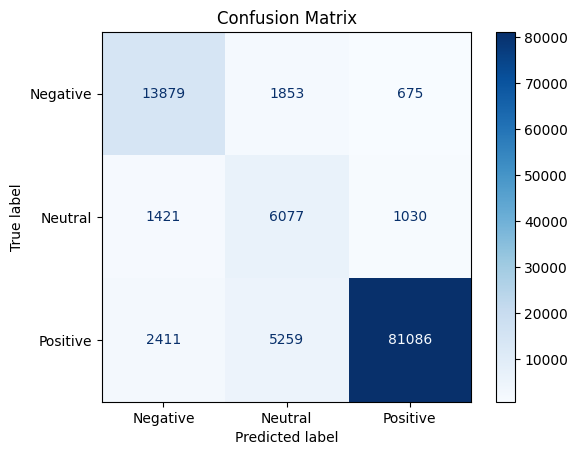

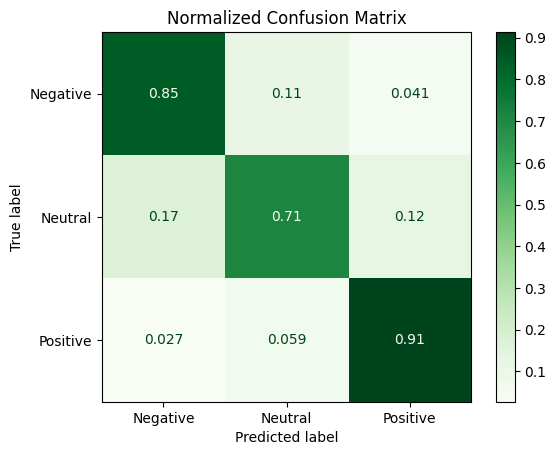

In [17]:
# confusion matrix
cm = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, 
    display_labels=['Negative','Neutral','Positive'
])
cm.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negative', 'Neutral', 'Positive'],
    normalize='true',
    cmap='Greens'
)
plt.title('Normalized Confusion Matrix')
plt.show()

In [15]:
# save model
model_path = root_dir / 'models' / 'tfidf_logreg.joblib'
joblib.dump(pipeline, model_path)

print('Model saved in models folder')

Model saved in models folder


In [16]:
X_test.to_csv(root_dir / 'data' / 'sentiment_X_test.csv', index=False)
pd.Series(y_test, name='Sentiment',).to_csv(root_dir / 'data' / 'sentiment_y_test.csv', index=False)

print('Test data saved in data folder')

Test data saved in data folder
